# Exploratory Data Analysis

Using the data we collected and cleaned

In this section, we will:

- Verify data quality (date range, data types, missing values, duplicates, and basic summary statistics).
- Visualize time-series trends in rent, home prices, and income to understand long-run patterns.
- Examine affordability metrics (Home Price-to-Income ratio and Rent Burden) over time.
- Analyze year-over-year (YoY) changes to compare growth rates between rent, home prices, and affordability.
- Explore relationships between variables (e.g., rent vs. home price, affordability vs. costs) using scatter plots and correlations.
- Summarize key insights from the visuals that directly relate to our research question and inform modeling/forecasting next steps.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf

sj_housing = pd.read_csv('../data/processed/sj_housing_final.csv')
sj_housing.head()

,date,rent,home_price,year,median_household_income,HPI,rent_burden,rent_yoy,price_yoy,HPI_yoy
0,2015-01-31,2442.261478,757953.079907,2015,102340.0,7.406225,0.286370,NaN,NaN,NaN
1,2015-02-28,2451.852475,767196.560902,2015,102340.0,7.496546,0.287495,NaN,NaN,NaN
2,2015-03-31,2471.268835,772689.807192,2015,102340.0,7.550223,0.289772,NaN,NaN,NaN
3,2015-04-30,2507.208362,775291.415394,2015,102340.0,7.575644,0.293986,NaN,NaN,NaN
4,2015-05-31,2565.092154,777993.176600,2015,102340.0,7.602044,0.300773,NaN,NaN,NaN


In [4]:
# Make sure date is datetime
sj_housing["date"] = pd.to_datetime(sj_housing["date"])

# Sort by date
sj_housing = sj_housing.sort_values("date").reset_index(drop=True)

print("=== Data Information ===")
print("Rows, Columns:", sj_housing.shape)
print("Start:", sj_housing["date"].min())
print("End:  ", sj_housing["date"].max())
print("Unique years:", sj_housing["year"].nunique())
print()

# Check if dates are monthly and continuous
dates = sj_housing["date"].dropna().sort_values()
month_gaps = dates.diff().dropna()

# Missing values
print("=== Missing Values ===")
print(sj_housing.isna().sum().sort_values(ascending=False))
print()

# Quick summary stats for numeric columns
print("=== Summary Stats (numeric columns) ===")
display(sj_housing.describe(include=[np.number]).T)

=== Data Information ===
Rows, Columns: (132, 10)
Start: 2015-01-31 00:00:00
End:   2025-12-31 00:00:00
Unique years: 11

=== Missing Values ===
HPI_yoy                    48
median_household_income    24
HPI                        24
rent_burden                24
rent_yoy                   12
price_yoy                  12
date                        0
rent                        0
home_price                  0
year                        0
dtype: int64

=== Summary Stats (numeric columns) ===


,count,mean,std,min,25%,50%,75%,max
rent,132.0,2.935140e+03,239.039082,2442.261478,2739.076676,2.909656e+03,3.137333e+03,3.413661e+03
home_price,132.0,1.177010e+06,257426.060072,757953.079907,898696.459892,1.151302e+06,1.428654e+06,1.576510e+06
year,132.0,2.020000e+03,3.174324,2015.000000,2017.000000,2.020000e+03,2.023000e+03,2.025000e+03
median_household_income,108.0,1.341817e+05,20517.602664,102340.000000,119035.000000,1.330760e+05,1.508390e+05,1.681540e+05
HPI,108.0,8.450531e+00,0.746295,7.025616,7.786875,8.562955e+00,9.087056e+00,9.993428e+00
rent_burden,108.0,2.623906e-01,0.023934,0.222560,0.242397,2.638184e-01,2.807402e-01,3.126096e-01
rent_yoy,120.0,2.743094e-02,0.039491,-0.086620,0.016436,3.221284e-02,4.244770e-02,1.090904e-01
price_yoy,120.0,7.189071e-02,0.097962,-0.119702,-0.000969,7.219881e-02,1.336092e-01,3.041776e-01
HPI_yoy,84.0,1.265112e-02,0.096483,-0.143079,-0.058994,3.690288e-03,6.373575e-02,2.261882e-01


## Data is clean enough for grapphing

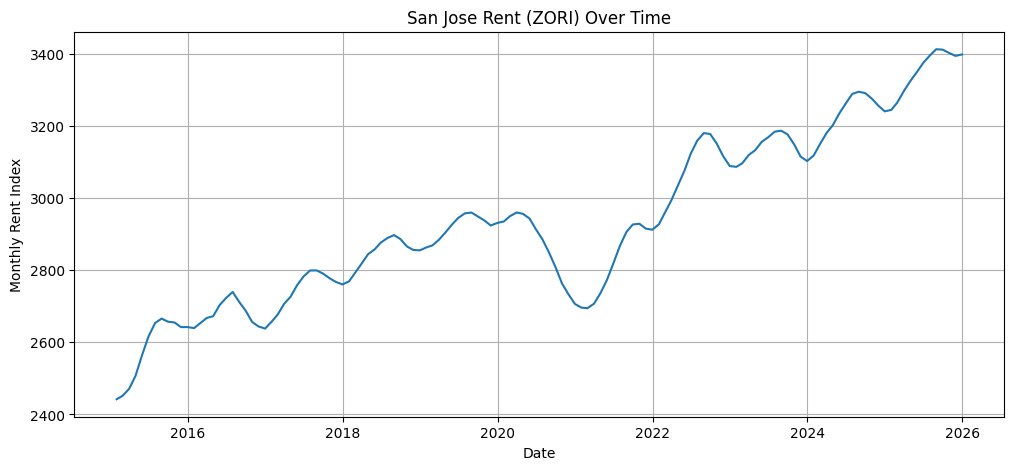

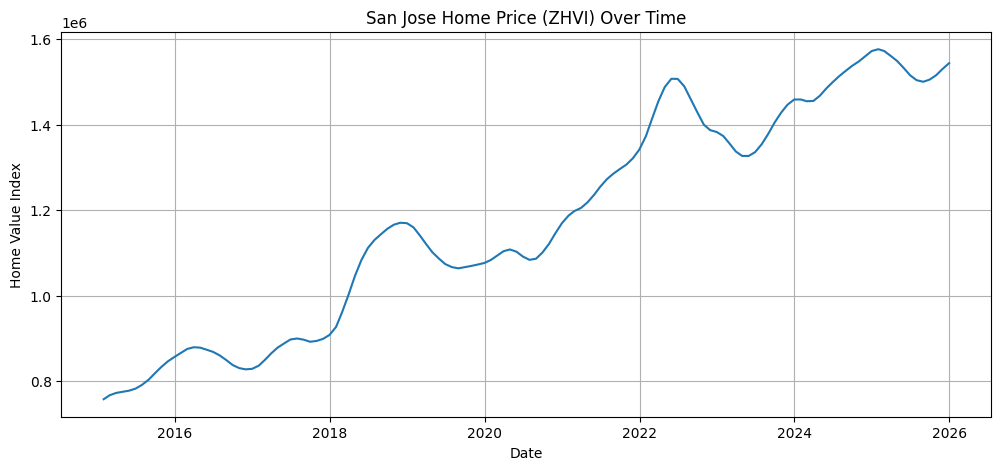

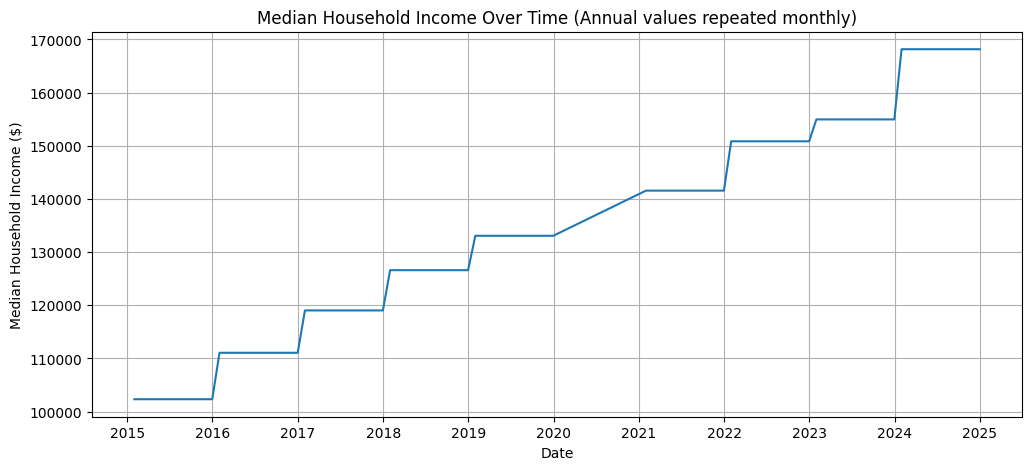

In [5]:
sj_housing["date"] = pd.to_datetime(sj_housing["date"])
sj_housing = sj_housing.sort_values("date").reset_index(drop=True)

eda_all = sj_housing.copy()
eda_income = sj_housing.dropna(subset=["median_household_income"]).copy()

# Rent over time
plt.figure(figsize=(12,5))
plt.plot(eda_all["date"], eda_all["rent"])
plt.title("San Jose Rent (ZORI) Over Time")
plt.xlabel("Date")
plt.ylabel("Monthly Rent Index")
plt.grid(True)
plt.show()

# Home price over time
plt.figure(figsize=(12,5))
plt.plot(eda_all["date"], eda_all["home_price"])
plt.title("San Jose Home Price (ZHVI) Over Time")
plt.xlabel("Date")
plt.ylabel("Home Value Index")
plt.grid(True)
plt.show()

# Median household income over time (annual but repeated monthly)
plt.figure(figsize=(12,5))
plt.plot(eda_income["date"], eda_income["median_household_income"])
plt.title("Median Household Income Over Time (Annual values repeated monthly)")
plt.xlabel("Date")
plt.ylabel("Median Household Income ($)")
plt.grid(True)
plt.show()

## Interpretation of Housing and Income Trends (2015–2025)

The three time-series plots show clear long-run upward trends in **San Jose rents (ZORI)**, **San Jose home values (ZHVI)**, and **median household income (Santa Clara County)** from 2015 through the most recent observations. While all series rise over time, they do so with noticeably different patterns and volatility.

### Rent (ZORI) Over Time
- The rent index rises steadily across the period, increasing from roughly the mid-$2,400 range in 2015 to the mid-$3,300 range by 2025.
- The trend is mostly smooth and gradual, indicating persistent rent growth over time.
- A visible dip occurs around **2020–2021**, followed by a recovery and faster growth beginning around **2022**.
- Compared to home prices, rent changes appear **less volatile** and more incremental.

### Home Price (ZHVI) Over Time
- Home values increase substantially over the period, with **larger swings** than rent.
- Prices rise through 2015–2019, then show volatility around **2020–2022**.
- After a strong run-up into **2022**, home prices decline and then rebound again through **2024–2025**, approaching or reaching prior highs.
- Overall, home prices exhibit stronger boom-and-cooldown cycles, suggesting ownership costs are more sensitive to market shifts than rent.

### Median Household Income Over Time
- Median household income trends upward from a little above **100k (2015)** to roughly the **high-160k range (2024–2025)**.
- The “step-like” pattern is expected because income is **annual ACS data repeated monthly**.
- The overall direction indicates meaningful income growth over the decade, especially in the later years.

### Implications for Affordability
- Both rent and home prices rise over time, implying continued increases in housing costs in the San Jose region.
- Home prices show greater volatility than rent, implying that **ownership affordability may be more unstable** than rental affordability across the period.
- Strong income growth can partially offset affordability pressures when computing affordability ratios (e.g., rent burden, price-to-income).
- Because income is **county-level** and represents the median across **all households** (not renter-only households), affordability interpretations—especially for rent burden—should be made with caution.

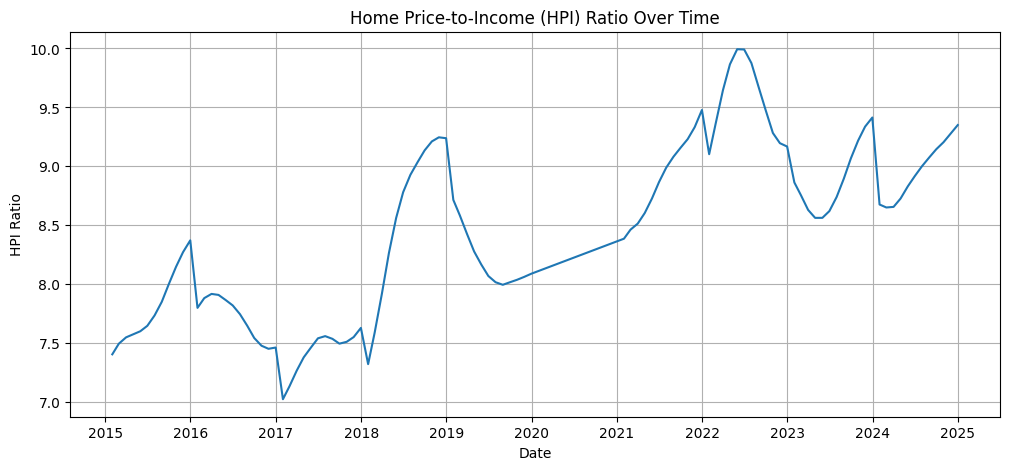

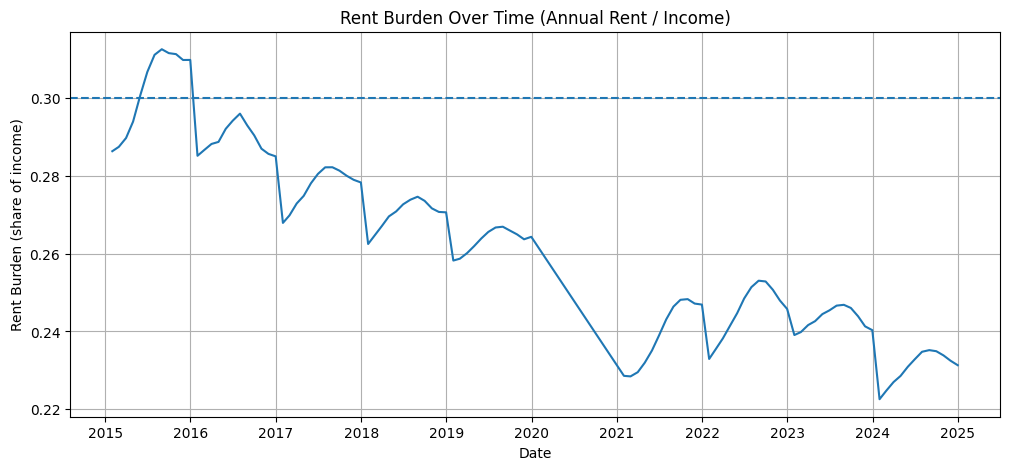

In [6]:
# HPI ratio over time
plt.figure(figsize=(12,5))
plt.plot(eda_income["date"], eda_income["HPI"])
plt.title("Home Price-to-Income (HPI) Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("HPI Ratio")
plt.grid(True)
plt.show()

# Rent burden over time
plt.figure(figsize=(12,5))
plt.plot(eda_income["date"], eda_income["rent_burden"])
plt.title("Rent Burden Over Time (Annual Rent / Income)")
plt.xlabel("Date")
plt.ylabel("Rent Burden (share of income)")
plt.axhline(0.30, linestyle="--")
plt.grid(True)
plt.show()

## Interpretation of Affordability Metrics (2015–2025)

The following plots summarize affordability using two ratios: the **Home Price-to-Income (HPI) ratio** and **Rent Burden (annual rent / income)**. Because both metrics are constructed using the same income series, they provide a direct view of how housing costs have changed relative to household earnings over time.

### Home Price-to-Income (HPI) Ratio Over Time
- The HPI ratio fluctuates between roughly **7 and 10** over the period, indicating that typical home values are consistently several times larger than the median household income.
- From **2015-2017**, the ratio stays in the mid-to-high 7 range, with a brief dip around 2017.
- A sharp increase occurs around **2018–2019**, where the ratio rises above **9**, suggesting home prices began outpacing income growth more strongly during that period.
- The ratio climbs again into **2021–2022**, peaking near **10**, consistent with the major run-up in home prices during that time.
- After the 2022 peak, the ratio falls during **2022–2023** and then partially rebounds through **2024–2025**, remaining elevated relative to the early years.
- Overall, the HPI ratio suggests that **homeownership affordability worsened over time**, with the most strained period occurring around **2022**.

### Rent Burden Over Time (Annual Rent / Income)
- Rent burden begins near **0.29–0.31** in 2015–2016, occasionally exceeding the **0.30** reference line (commonly used as a “cost-burdened” benchmark).
- After 2016, the trend generally moves downward, reaching the **mid-0.20s** by 2018–2019.
- A more pronounced drop appears around **2020–2021**, with rent burden reaching approximately the **low-0.20s**, followed by modest rebounds and fluctuations afterward.
- By **2024–2025**, rent burden remains around the **0.22–0.24** range, well below the 0.30 benchmark.

### Interpretation and Caution
- Taken at face value, these metrics imply that **home price affordability deteriorated more strongly than rent affordability** over the sample period: the HPI ratio rises and remains elevated, while rent burden declines.
- The downward trend in rent burden may be influenced by the choice of income series (county-level median household income, representing all households) and the use of a metro-level rent index. As a result, the rent burden metric may not fully capture renter-specific affordability pressures.
- Despite this limitation, the combination of high and volatile HPI ratios suggests that **ownership affordability remains a major constraint** in the San Jose region, especially during the 2021–2022 price surge.

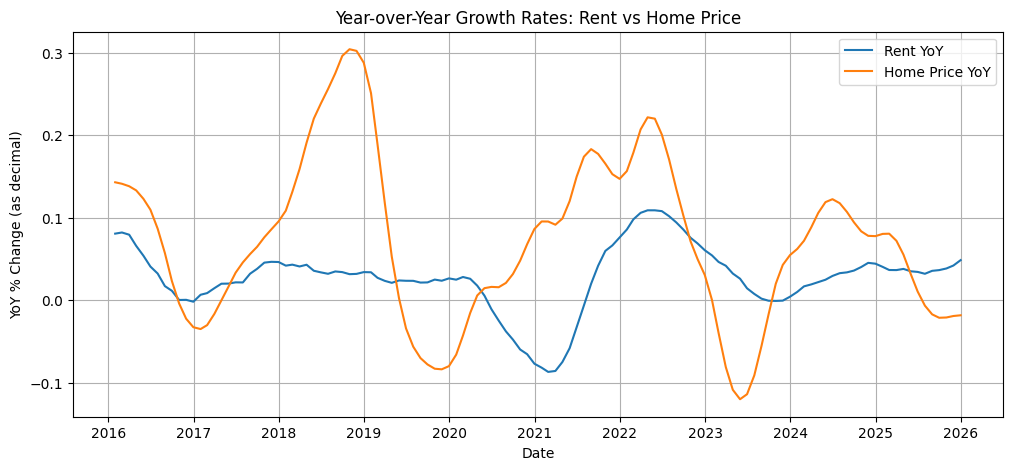

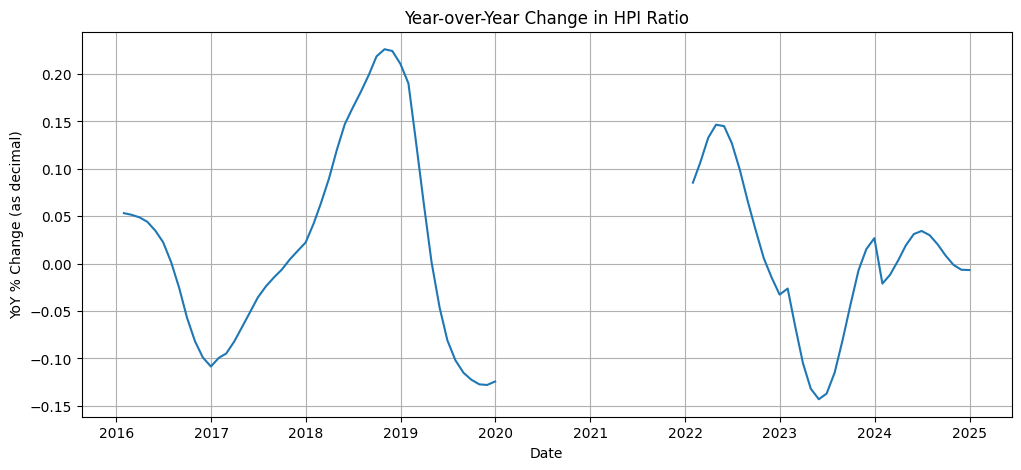

In [7]:
plt.figure(figsize=(12,5))
plt.plot(eda_all["date"], eda_all["rent_yoy"], label="Rent YoY")
plt.plot(eda_all["date"], eda_all["price_yoy"], label="Home Price YoY")
plt.title("Year-over-Year Growth Rates: Rent vs Home Price")
plt.xlabel("Date")
plt.ylabel("YoY % Change (as decimal)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(eda_income["date"], eda_income["HPI_yoy"])
plt.title("Year-over-Year Change in HPI Ratio")
plt.xlabel("Date")
plt.ylabel("YoY % Change (as decimal)")
plt.grid(True)
plt.show()

## Interpretation of Year-over-Year (YoY) Changes (2016–2025)

These plots show **year-over-year percentage changes** for (1) rent and home prices, and (2) the Home Price-to-Income (HPI) ratio. YoY changes measure how much a value has increased or decreased compared to the same month one year earlier, helping highlight periods of rapid growth, slowdowns, or declines.

### YoY Growth Rates: Rent vs. Home Price
- **Home prices are consistently more volatile than rent.** The home price YoY series shows larger spikes and deeper drops, while rent YoY moves within a narrower band.
- The home price YoY growth rate reaches a major peak around **2018–2019**, indicating a period of rapid appreciation, followed by a sharp slowdown and negative growth around **2019–2020**.
- Around **2021–2022**, home prices again show strong positive YoY growth, followed by another downturn into **2023**, where YoY home price growth becomes negative before recovering.
- Rent YoY growth is comparatively smoother:
  - Rent growth stays mildly positive for much of the period.
  - A dip into negative rent growth appears around **2020–2021**, followed by a strong rebound into **2022**, and then moderation afterward.
- Overall, the comparison suggests that rental costs change more gradually, while home prices experience stronger boom-bust cycles.

### YoY Change in HPI Ratio
- The YoY change in the HPI ratio reflects whether home prices are increasing faster or slower than income:
  - **Positive HPI YoY** implies affordability is worsening (prices rising faster than income).
  - **Negative HPI YoY** implies affordability is improving (prices rising slower than income, or falling relative to income).
- A strong positive surge in HPI YoY occurs around **2018–2019**, consistent with the rapid home price growth seen in the rent vs. price comparison plot.
- The HPI YoY then falls into negative territory around **2019–2020**, indicating a period where the price-to-income relationship improved relative to the peak (either due to slowing home prices, rising income, or both).
- Later, the HPI YoY becomes positive again around **2022**, then turns negative around **2023**, and finally stabilizes closer to zero by **2024–2025**, suggesting a moderation in affordability changes in the most recent period.
- Note: Gaps in the HPI YoY plot are expected when the underlying HPI series is missing for certain years (due to missing income values), which prevents the YoY calculation.

### Overall Takeaway
- The YoY results reinforce that **home prices drive most of the volatility in affordability**, while rent growth is more stable.
- Periods of rapidly rising home prices (e.g., **2018–2019** and **2021–2022**) correspond to sharp increases in the HPI ratio, indicating worsening ownership affordability during those phases.

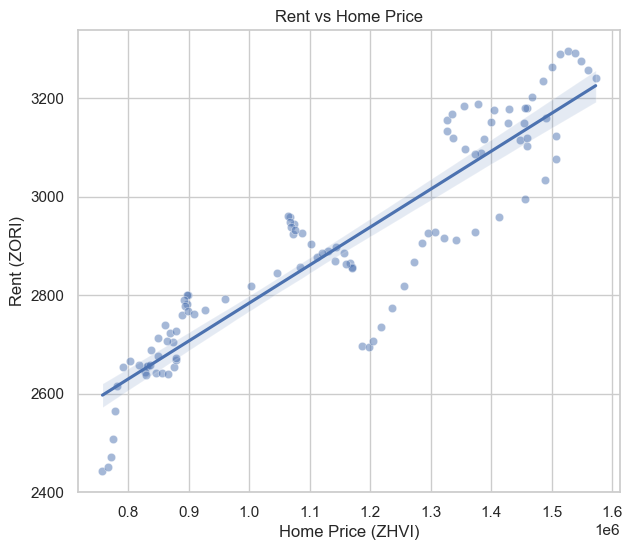

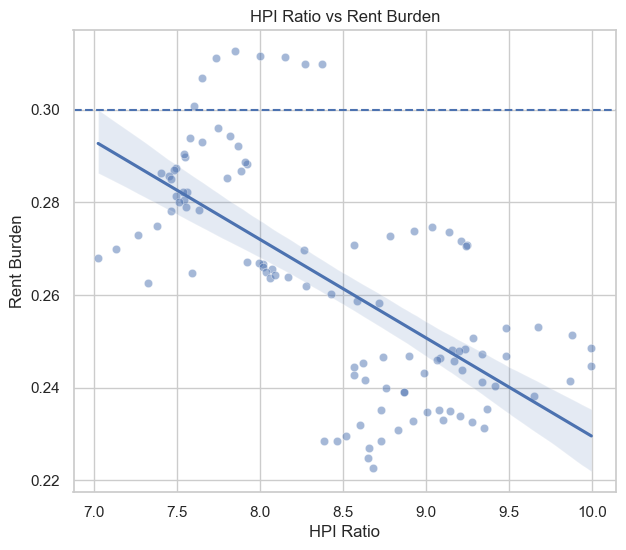

In [21]:
# Rent vs Home Price
plt.figure(figsize=(7,6))
sns.scatterplot(data=eda_income, x="home_price", y="rent", alpha=0.5)
sns.regplot(data=eda_income, x="home_price", y="rent", scatter=False)  # trend line
plt.title("Rent vs Home Price")
plt.xlabel("Home Price (ZHVI)")
plt.ylabel("Rent (ZORI)")
plt.show()

# HPI vs Rent Burden
plt.figure(figsize=(7,6))
sns.scatterplot(data=eda_income, x="HPI", y="rent_burden", alpha=0.5)
sns.regplot(data=eda_income, x="HPI", y="rent_burden", scatter=False)
plt.axhline(0.30, linestyle="--")
plt.title("HPI Ratio vs Rent Burden")
plt.xlabel("HPI Ratio")
plt.ylabel("Rent Burden")
plt.show()

## Interpretation of Variable Relationships (Scatter Plots)

The following scatter plots examine how key housing and affordability variables move relative to one another. Trend lines summarize the overall direction of the relationship.

### Rent vs. Home Price
- The scatter plot shows a **strong positive relationship** between home prices (ZHVI) and rent (ZORI): as home values increase, rents also tend to be higher.
- The upward-sloping trend line indicates that periods associated with higher home prices generally coincide with higher rent levels, suggesting shared market drivers (e.g., demand, supply constraints, regional economic conditions).
- The points show some spread around the trend line, meaning rent does not move perfectly one-for-one with home prices; however, the overall pattern is clearly increasing.
- The clustering of points into “groups” likely reflects different market phases over time (e.g., pre-2020 levels, pandemic-era shifts, and the post-2022 period).

### HPI Ratio vs. Rent Burden
- The second plot shows a **negative relationship** between the HPI ratio and rent burden: higher HPI values (worse homeownership affordability) are associated with lower rent burden in this dataset.
- This pattern is not necessarily intuitive as a real-world statement about affordability; rather, it likely reflects how the metric is constructed:
  - **HPI** is sensitive to rapid changes in home prices, which were highly volatile during this period.
  - **Rent burden** depends heavily on the income series used (county-level median household income), which increased strongly and can reduce the burden ratio even when rents rise.
- The downward-sloping trend suggests that ownership affordability and rental affordability **do not move together** in a simple way in this construction, and that the two metrics may be capturing different dynamics.
- The dashed horizontal line at **0.30** indicates the commonly used “cost-burdened” threshold. Many early observations cluster near or above this line, while later observations fall below it, consistent with the downward trend observed in rent burden over time.

### Takeaway
- Rent and home prices appear to rise together in the long run (positive relationship).
- In contrast, the affordability metrics (HPI vs. rent burden) show an inverse relationship in this dataset, emphasizing that results depend on the specific data sources and definitions used—especially for income and rent burden.

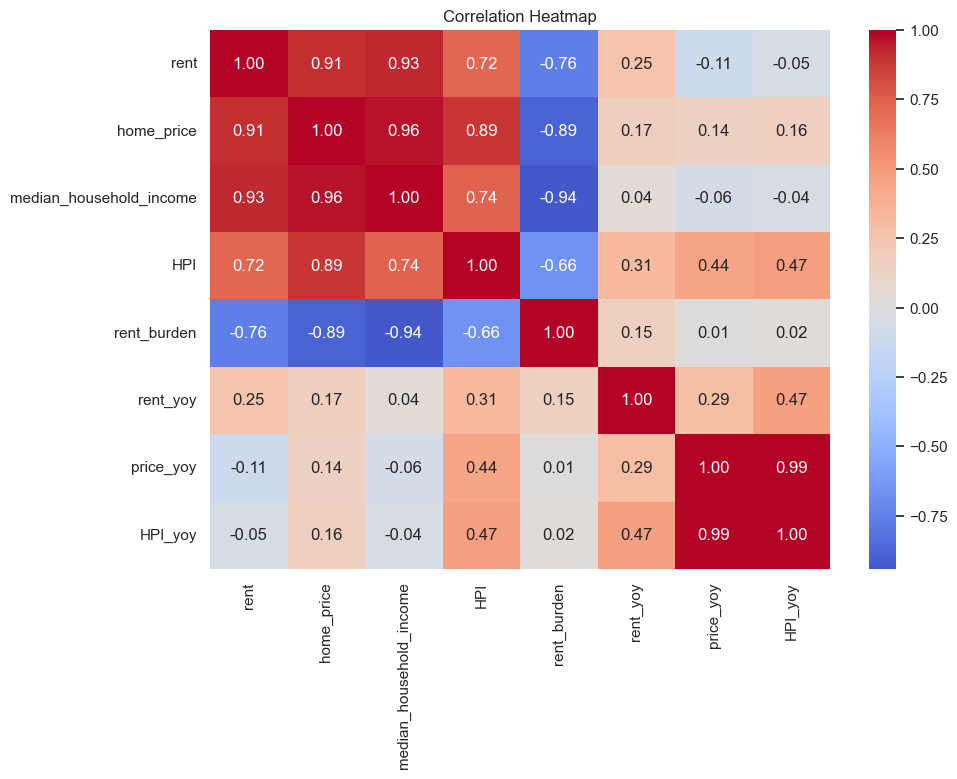

In [22]:
cols = ["rent", "home_price", "median_household_income", "HPI", "rent_burden",
        "rent_yoy", "price_yoy", "HPI_yoy"]

corr = eda_income[cols].corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Interpretation of Correlation Heatmap

The correlation heatmap summarizes the strength and direction of linear relationships between the main housing variables, income, affordability metrics, and their year-over-year (YoY) changes. Correlation values range from **-1** (strong negative relationship) to **+1** (strong positive relationship). Values closer to **0** indicate little linear relationship.

### Key Relationships in Levels (Rent, Home Price, Income)
- **Rent and home prices are strongly positively correlated (0.91)**, indicating that higher home values tend to coincide with higher rent levels in the San Jose region.
- **Income is also strongly positively correlated with both rent (0.93) and home prices (0.96)**. This likely reflects that all three series generally trend upward over time; as the regional economy and incomes rise, housing costs tend to rise as well.

### Affordability Metrics (HPI and Rent Burden)
- The **HPI ratio** is strongly correlated with **home prices (0.89)** and moderately correlated with **income (0.74)** and **rent (0.72)**. This makes sense because HPI is directly constructed from home prices and income, and home prices appear to be the dominant driver.
- **Rent burden shows strong negative correlations** with:
  - **income (-0.94)**,
  - **home prices (-0.89)**,
  - **rent (-0.76)**, and
  - **HPI (-0.66)**.
  
  This indicates that in this dataset, rent burden tends to be lower when income (and other level variables) are higher. This pattern is consistent with the rent burden time-series trend declining over time and likely reflects how strongly the income series increases relative to rent within the observed period.

### Relationships in Growth Rates (YoY Variables)
- The **strongest relationship among growth variables is between home price YoY and HPI YoY (0.99)**. This implies that year-to-year changes in affordability (HPI YoY) are driven overwhelmingly by year-to-year changes in home prices rather than income.
- **Rent YoY has only weak-to-moderate correlations** with other YoY metrics (e.g., ~0.29 with price YoY and ~0.47 with HPI YoY), reinforcing that rent growth is generally smoother and does not move as tightly with home price growth.
- YoY variables show weak relationships with the level variables overall (many correlations near 0), which is common because growth rates capture short-term fluctuations while levels capture long-term trends.

### Takeaway
- The heatmap supports two main conclusions:
  1. **Housing costs and income all trend upward together** (strong positive correlations among rent, home price, and income).
  2. **Changes in homeownership affordability are primarily driven by home price movements**, as shown by the extremely high correlation between **price YoY** and **HPI YoY**.
- Because correlations can be inflated by shared upward trends over time, these results should be interpreted as descriptive associations rather than causal relationships.

In [11]:
tmp = sj_housing.dropna(subset=["median_household_income"]).copy()

start = tmp.iloc[0]
end = tmp.iloc[-1]

rent_growth = (end["rent"] / start["rent"] - 1)
income_growth = (end["median_household_income"] / start["median_household_income"] - 1)

rent_burden_start = (start["rent"]*12) / start["median_household_income"]
rent_burden_end   = (end["rent"]*12) / end["median_household_income"]

print("Rent growth:", rent_growth)
print("Income growth:", income_growth)
print("Rent burden start:", rent_burden_start)
print("Rent burden end:", rent_burden_end)

Rent growth: 0.32714931261053426
Income growth: 0.6430916552667578
Rent burden start: 0.28637031209473757
Rent burden end: 0.23130551581244113


In [12]:
eda_all = sj_housing.copy()
eda_income = sj_housing.dropna(subset=["median_household_income", "HPI", "rent_burden"]).copy()

# Correlations (levels)
corr_cols = ["rent", "home_price", "median_household_income", "HPI", "rent_burden"]
display(eda_income[corr_cols].corr())

,rent,home_price,median_household_income,HPI,rent_burden
rent,1.000000,0.911660,0.927848,0.724420,-0.757862
home_price,0.911660,1.000000,0.964236,0.886764,-0.893312
median_household_income,0.927848,0.964236,1.000000,0.735266,-0.941005
HPI,0.724420,0.886764,0.735266,1.000000,-0.663387
rent_burden,-0.757862,-0.893312,-0.941005,-0.663387,1.000000


## Key Findings (EDA)

- Median household income shows a step-like upward trend because annual ACS values are repeated across months.
- Rent and home prices both increase over time, reflecting rising housing costs in the San Jose region.
- Home prices exhibit larger swings over time than rent, especially when comparing year-over-year changes.
- Rent burden trends downward over the sample period in this dataset, indicating rent grew more slowly than the income series used (Santa Clara County median household income).
- This rent burden result should be interpreted with caution because the numerator (metro rent index) and denominator (county-wide household income) represent different populations and may not reflect renter-specific affordability.
- Overall, the dataset suggests affordability pressures may be more pronounced in homeownership metrics (HPI) and home price volatility than in the rent burden metric as constructed.